In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.formula.api as smf
import math

In [2]:
Sales=pd.read_csv(r"C:\Users\anany\Downloads\Chocolate Sales (2) (1).csv")

In [3]:
Sales

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184
...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,17/05/2024,"$5,303.58",354
3278,Jehu Rudeforth,USA,White Choc,07/06/2024,"$7,339.32",121
3279,Ches Bonnell,Canada,Organic Choco Syrup,26/07/2024,$616.09,238
3280,Dotty Strutley,India,Eclairs,28/07/2024,"$2,504.62",397


In [4]:
Sales['Date'] = pd.to_datetime(Sales['Date'], dayfirst=True)

In [5]:
Sales['Amount'] = Sales['Amount'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)

In [6]:
Sales['Amount'] = pd.to_numeric(Sales['Amount'])

In [7]:
Sales['Amount'] = Sales['Amount'].astype(int)

In [8]:
Sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   3282 non-null   object        
 1   Country        3282 non-null   object        
 2   Product        3282 non-null   object        
 3   Date           3282 non-null   datetime64[ns]
 4   Amount         3282 non-null   int64         
 5   Boxes Shipped  3282 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 154.0+ KB


In [9]:
Sales.rename(columns={"Product":"Product_Name"},inplace=True)

In [10]:
Sales['Price_Per_Box'] = Sales['Amount'] / Sales['Boxes Shipped'] # Added new coloumn price per box

In [11]:
Sales # As per shown in the previous part 

,Sales Person,Country,Product_Name,Date,Amount,Boxes Shipped,Price_Per_Box
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320,180,29.555556
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896,94,84.000000
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501,91,49.461538
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726,342,37.210526
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685,184,74.375000
...,...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,2024-05-17,5303,354,14.980226
3278,Jehu Rudeforth,USA,White Choc,2024-06-07,7339,121,60.652893
3279,Ches Bonnell,Canada,Organic Choco Syrup,2024-07-26,616,238,2.588235
3280,Dotty Strutley,India,Eclairs,2024-07-28,2504,397,6.307305


In [55]:
Sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   3282 non-null   object        
 1   Country        3282 non-null   object        
 2   Product_Name   3282 non-null   object        
 3   Date           3282 non-null   datetime64[ns]
 4   Amount         3282 non-null   int64         
 5   Boxes Shipped  3282 non-null   int64         
 6   Price_Per_Box  3282 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 179.6+ KB


DATA VISUALISATION (REMAINING GRAPHS)

Histogram

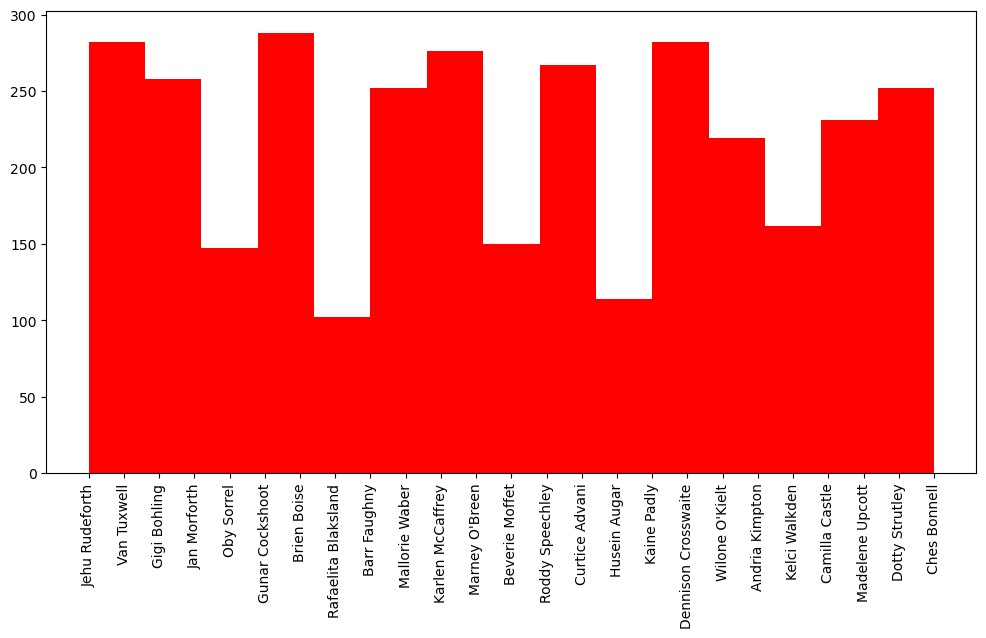

In [12]:
plt.figure(figsize=(12, 6))
plt.hist(Sales['Sales Person'],bins=15,color='red')
plt.xticks(rotation=90)
plt.show() # To represent histogram with bins

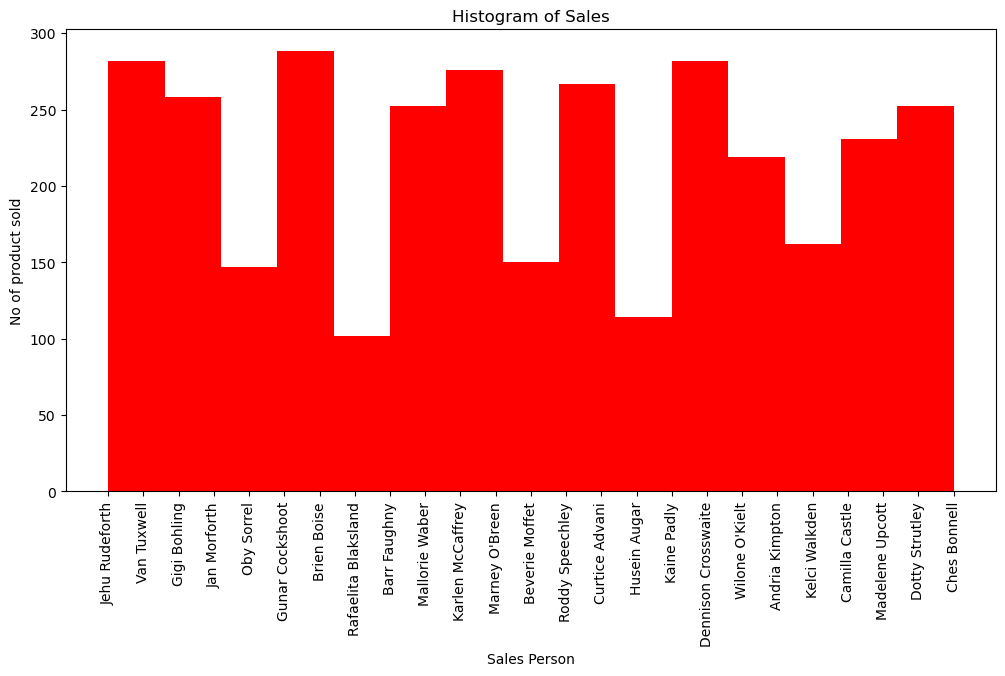

In [13]:
plt.figure(figsize=(12, 6))
plt.hist(Sales['Sales Person'],bins=15,color='red')
plt.xlabel('Sales Person')
plt.ylabel('No of product sold')
plt.title('Histogram of Sales')
plt.xticks(rotation=90)
plt.show() # To represent histogram with bins and labels

Displot

<Figure size 1200x600 with 0 Axes>

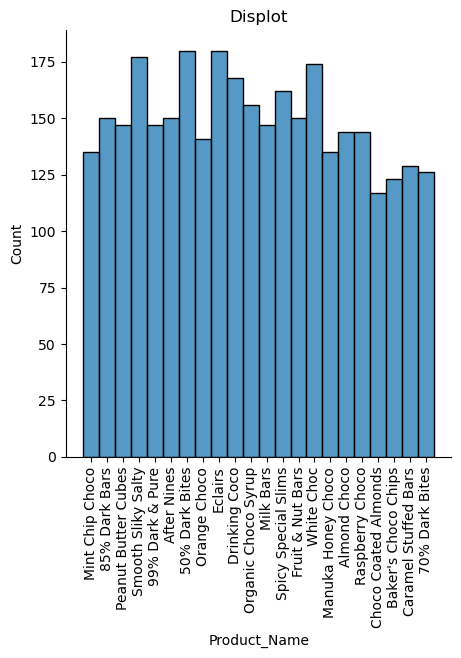

In [14]:
plt.figure(figsize=(12, 6))
sns.displot(data=Sales,x='Product_Name')
plt.title('Displot')
plt.xticks(rotation=90)
plt.show() # To represent displot of product name

<Figure size 1200x600 with 0 Axes>

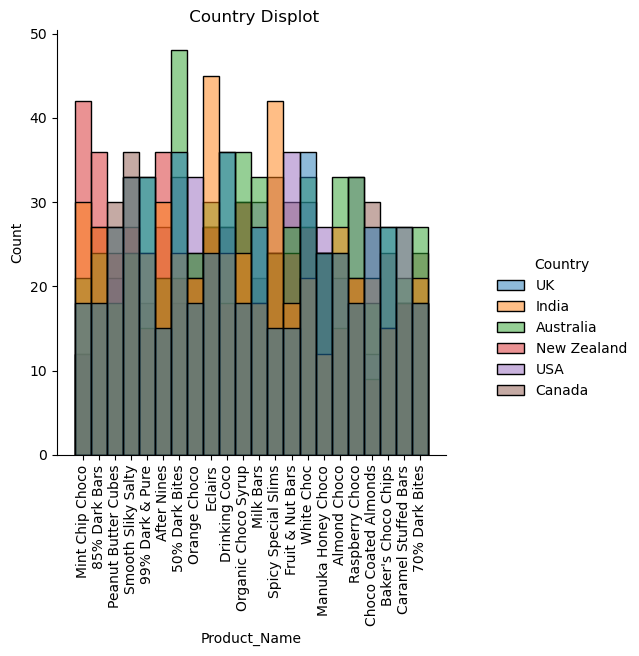

In [15]:
plt.figure(figsize=(12, 6))
sns.displot(data=Sales,x='Product_Name',hue='Country')
plt.title(' Country Displot')
plt.xticks(rotation=90)
plt.show()# To represent displot of product name and hue as Country

<Figure size 1200x600 with 0 Axes>

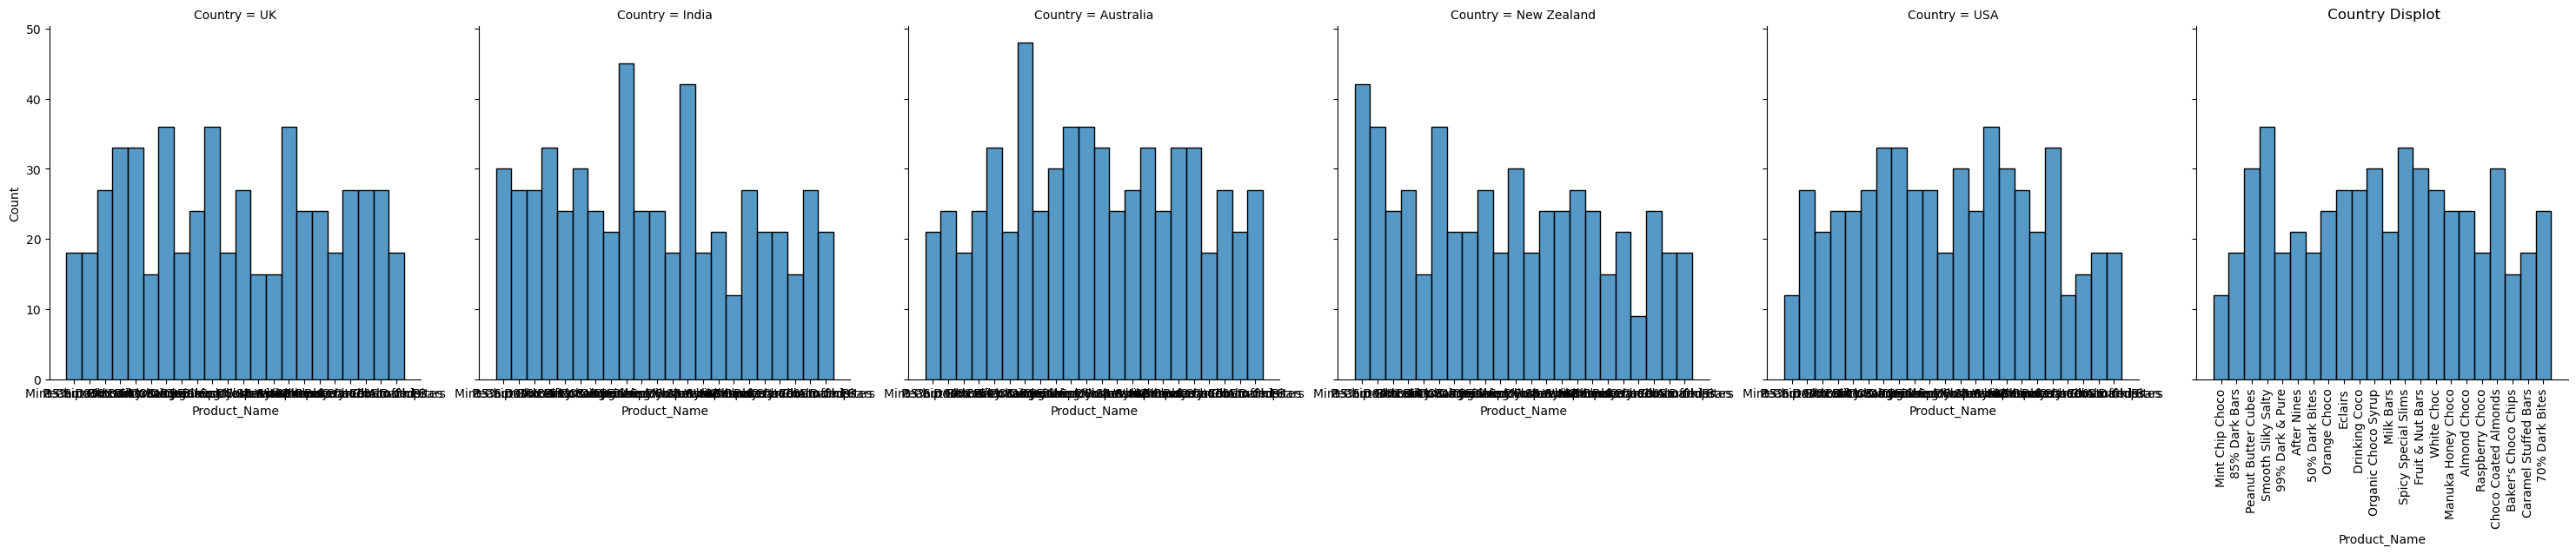

In [16]:
plt.figure(figsize=(12, 6))
sns.displot(data=Sales,x='Product_Name',col='Country')
plt.title(' Country Displot')
plt.xticks(rotation=90)
plt.show() # To represent displot of product name and col as Country

<Figure size 1200x600 with 0 Axes>

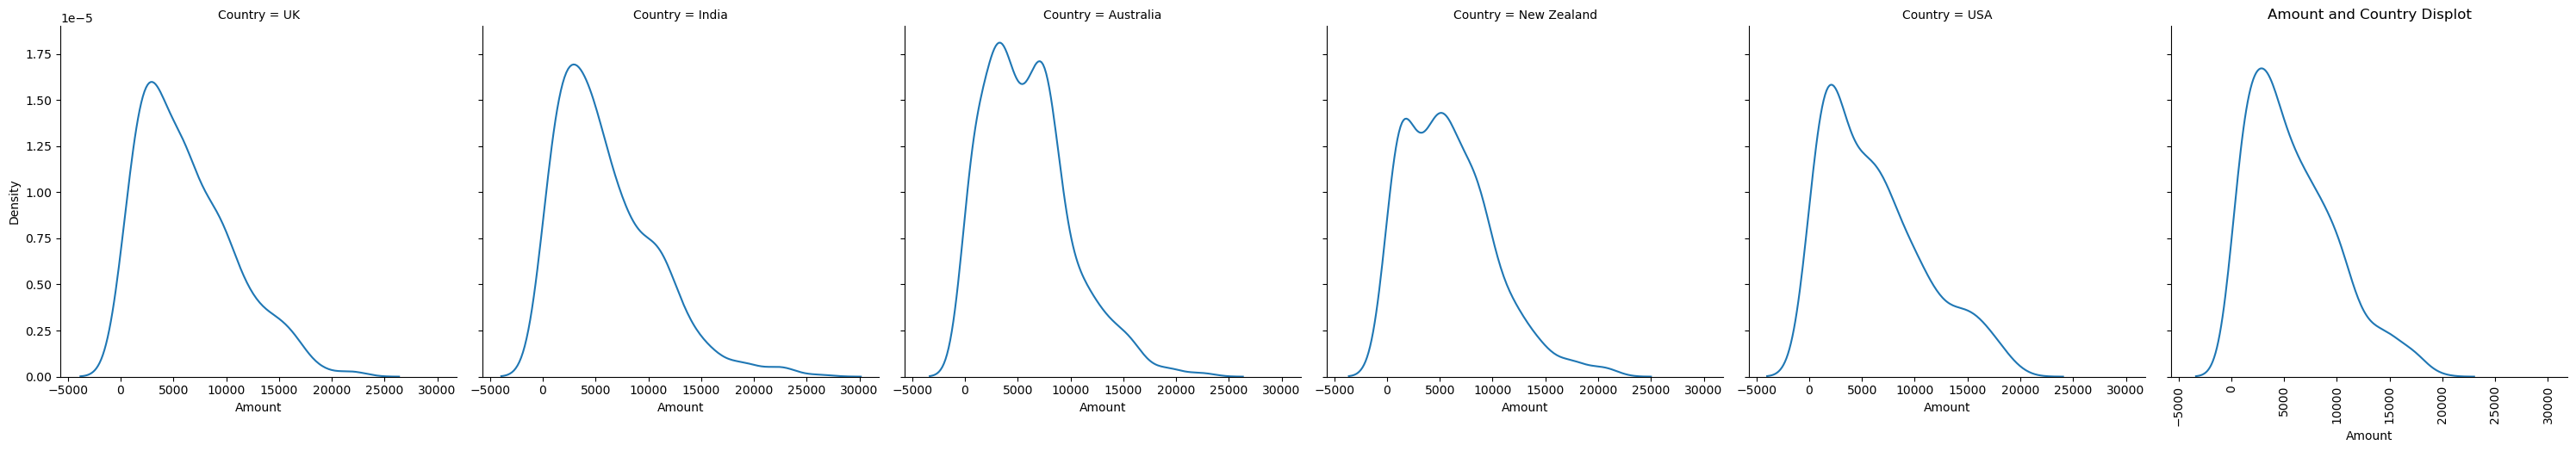

In [23]:
plt.figure(figsize=(12, 6))
sns.displot(data=Sales,x='Amount',col='Country',kind='kde')
plt.title('Amount and Country Displot')
plt.xticks(rotation=90)
plt.show()# To represent displot of Amount ,col as Country and kind as kde

<Figure size 1200x600 with 0 Axes>

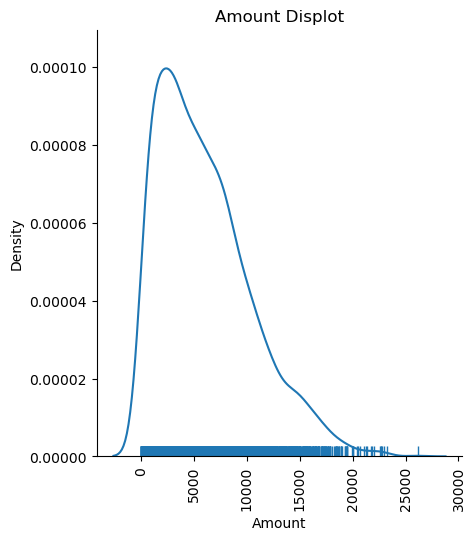

In [53]:
plt.figure(figsize=(12, 6))
sns.displot(data=Sales,x='Amount',rug=True,kind='kde')
plt.title('Amount Displot')
plt.xticks(rotation=90)
plt.show() # To represent displot of Amount and kind as kde

<Figure size 1200x600 with 0 Axes>

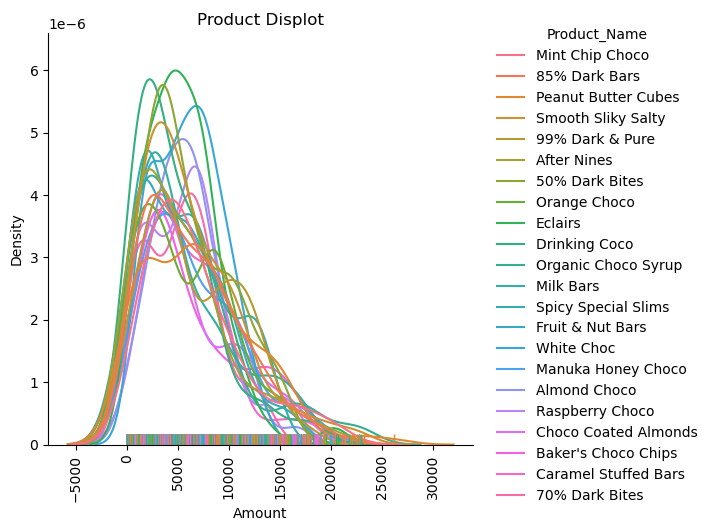

In [54]:
plt.figure(figsize=(12, 6))
sns.displot(data=Sales,x='Amount',rug=True,kind='kde',hue='Product_Name')
plt.title('Product Displot')
plt.xticks(rotation=90)
plt.show() # To represent displot of Amount ,hue as Product Name and kind as kde

<Figure size 1200x600 with 0 Axes>

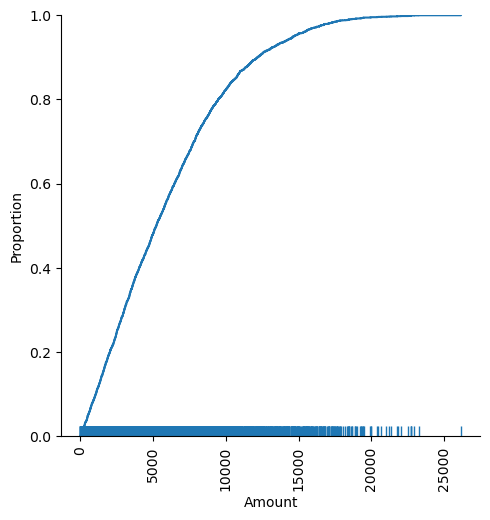

In [25]:
plt.figure(figsize=(12, 6))
sns.displot(data=Sales,x='Amount',rug=True,kind='ecdf')
plt.xticks(rotation=90)
plt.show() # To represent displot of Amount and kind as ecdf

<Figure size 1200x600 with 0 Axes>

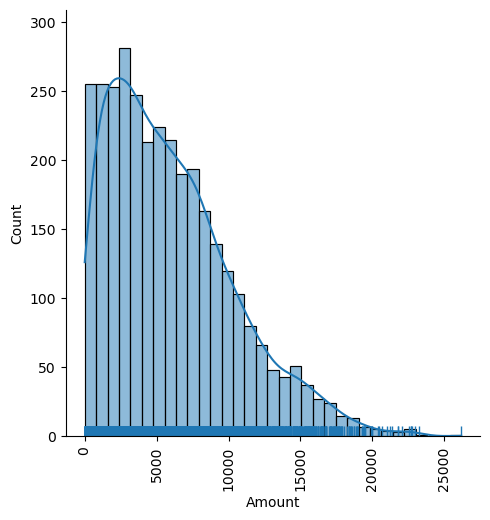

In [26]:
plt.figure(figsize=(12, 6))
sns.displot(data=Sales,x='Amount',rug=True,kde=True)
plt.xticks(rotation=90)
plt.show() # To represent displot of Amount and kde as True

<Figure size 1200x600 with 0 Axes>

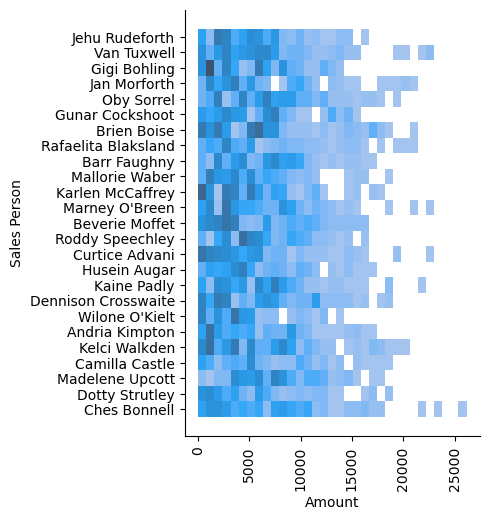

In [27]:
plt.figure(figsize=(12, 6))
sns.displot(data=Sales,x='Amount',y='Sales Person')
plt.xticks(rotation=90)
plt.show() # To represent displot of Amount and Sales Person

<Figure size 1200x600 with 0 Axes>

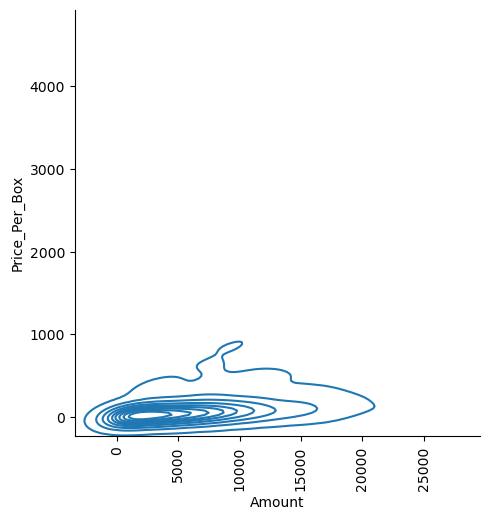

In [29]:
plt.figure(figsize=(12, 6))
sns.displot(data=Sales,x='Amount',y='Price_Per_Box',kind='kde')
plt.xticks(rotation=90)
plt.show() # To represent displot of Amount and Price_Per_Box and kind as kde

Catplot

<Figure size 1200x600 with 0 Axes>

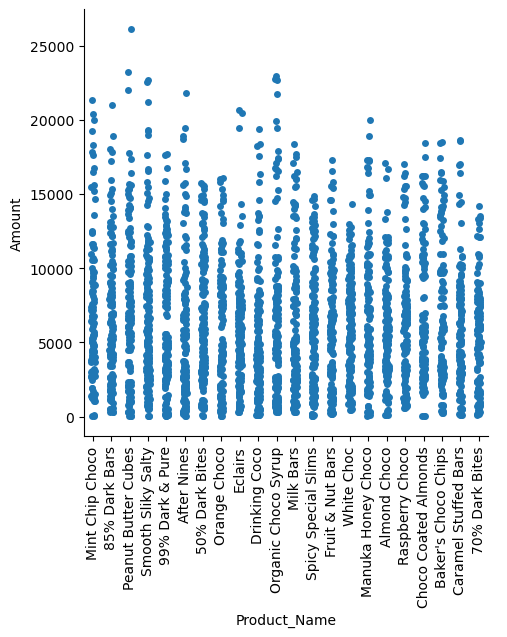

In [30]:
plt.figure(figsize=(12, 6))
sns.catplot(data=Sales,x="Product_Name",y="Amount")
plt.xticks(rotation=90)
plt.show() # To represent Catplot graph of product name and amount

<Figure size 1200x600 with 0 Axes>

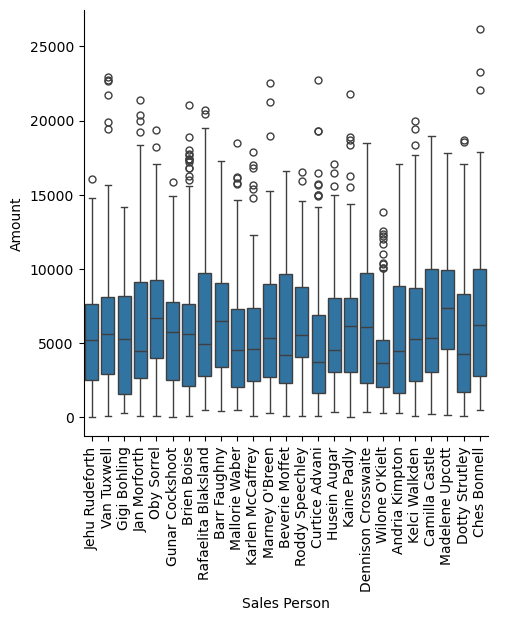

In [31]:
plt.figure(figsize=(12, 6))
sns.catplot(data=Sales,x="Sales Person",y="Amount",kind="box")
plt.xticks(rotation=90)
plt.show() # To represent Catplot graph of sales person and amount in box kind

<Figure size 1200x600 with 0 Axes>

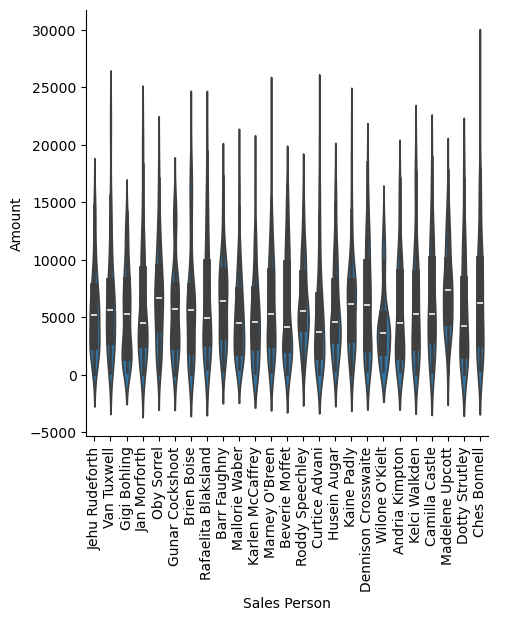

In [32]:
plt.figure(figsize=(12, 6))
sns.catplot(data=Sales,x="Sales Person",y="Amount",kind="violin")
plt.xticks(rotation=90)
plt.show() # To represent Catplot graph of sales person and amount in violin kind

<Figure size 1200x600 with 0 Axes>

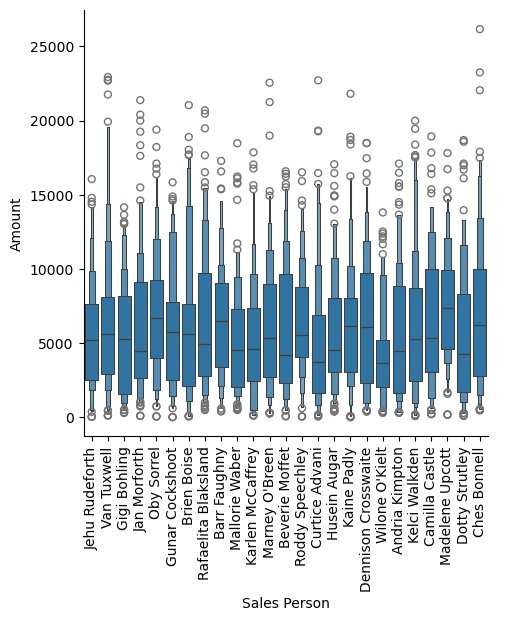

In [33]:
plt.figure(figsize=(12, 6))
sns.catplot(data=Sales,x="Sales Person",y="Amount",kind="boxen")
plt.xticks(rotation=90)
plt.show() # To represent Catplot graph of sales person and amount in boxen kind

<Figure size 1200x600 with 0 Axes>

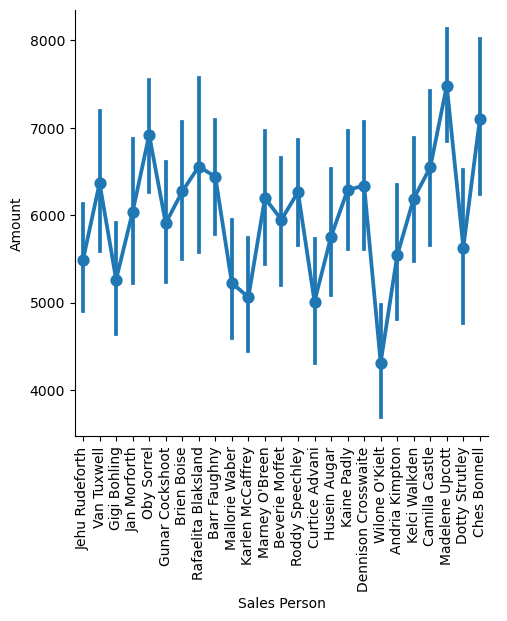

In [34]:
plt.figure(figsize=(12, 6))
sns.catplot(data=Sales,x="Sales Person",y="Amount",kind="point")
plt.xticks(rotation=90)
plt.show() # To represent Catplot graph of sales person and amount in point kind

<Figure size 1200x600 with 0 Axes>

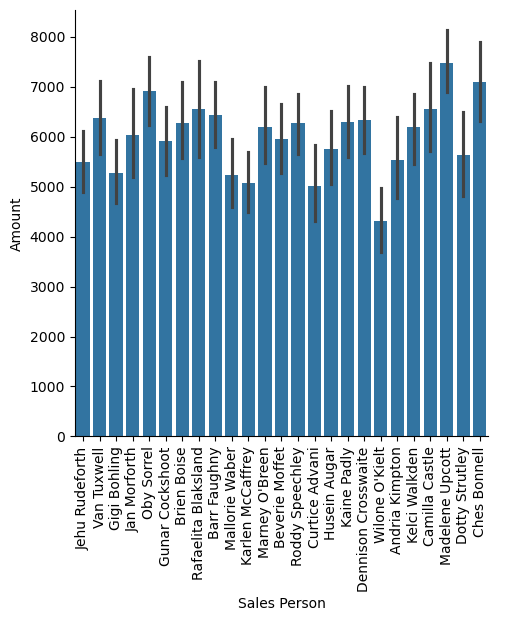

In [35]:
plt.figure(figsize=(12, 6))
sns.catplot(data=Sales,x="Sales Person",y="Amount",kind="bar")
plt.xticks(rotation=90)
plt.show() # To represent Catplot graph of sales person and amount in bar kind

<Figure size 1200x600 with 0 Axes>

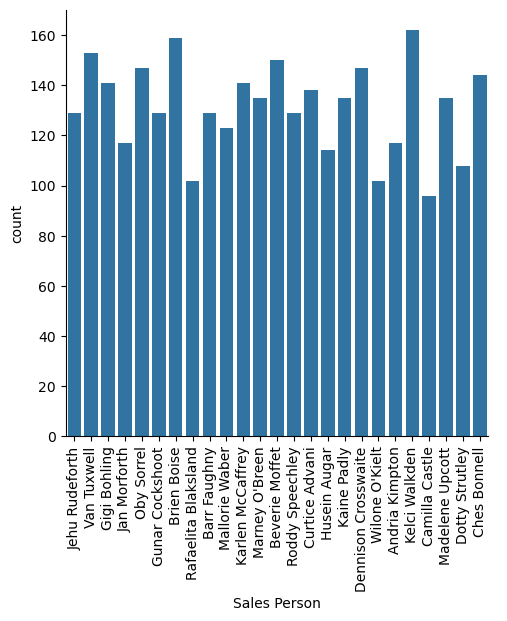

In [36]:
plt.figure(figsize=(12, 6))
sns.catplot(data=Sales,x="Sales Person",kind="count")
plt.xticks(rotation=90)
plt.show() # To represent Catplot graph of sales person and amount in count kind

<Figure size 1200x600 with 0 Axes>

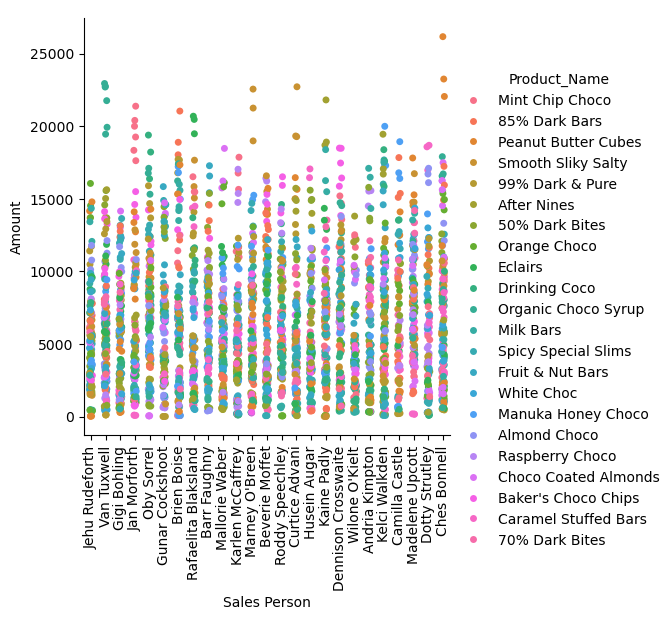

In [37]:
plt.figure(figsize=(12, 6))
sns.catplot(data=Sales,x="Sales Person",y="Amount",hue="Product_Name")
plt.xticks(rotation=90)
plt.show() # To represent Catplot graph of sales person and amount in hue as Product name

<Figure size 1200x600 with 0 Axes>

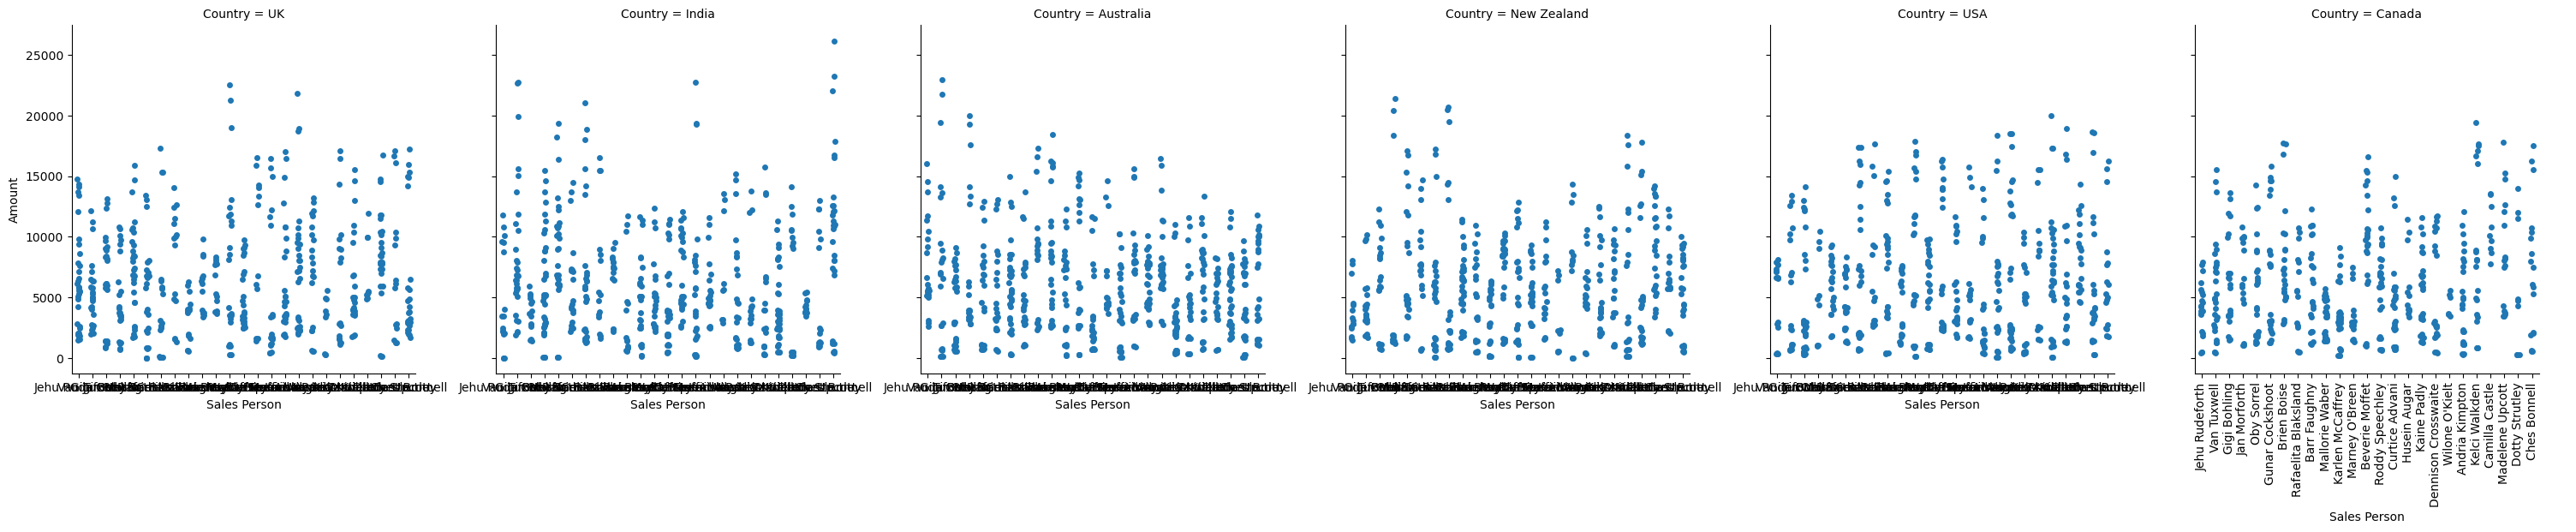

In [38]:
plt.figure(figsize=(12, 6))
sns.catplot(data=Sales,x="Sales Person",y="Amount",col="Country")
plt.xticks(rotation=90)
plt.show() # To represent Catplot graph of sales person and amount in col as country

Relplot

<Figure size 1200x600 with 0 Axes>

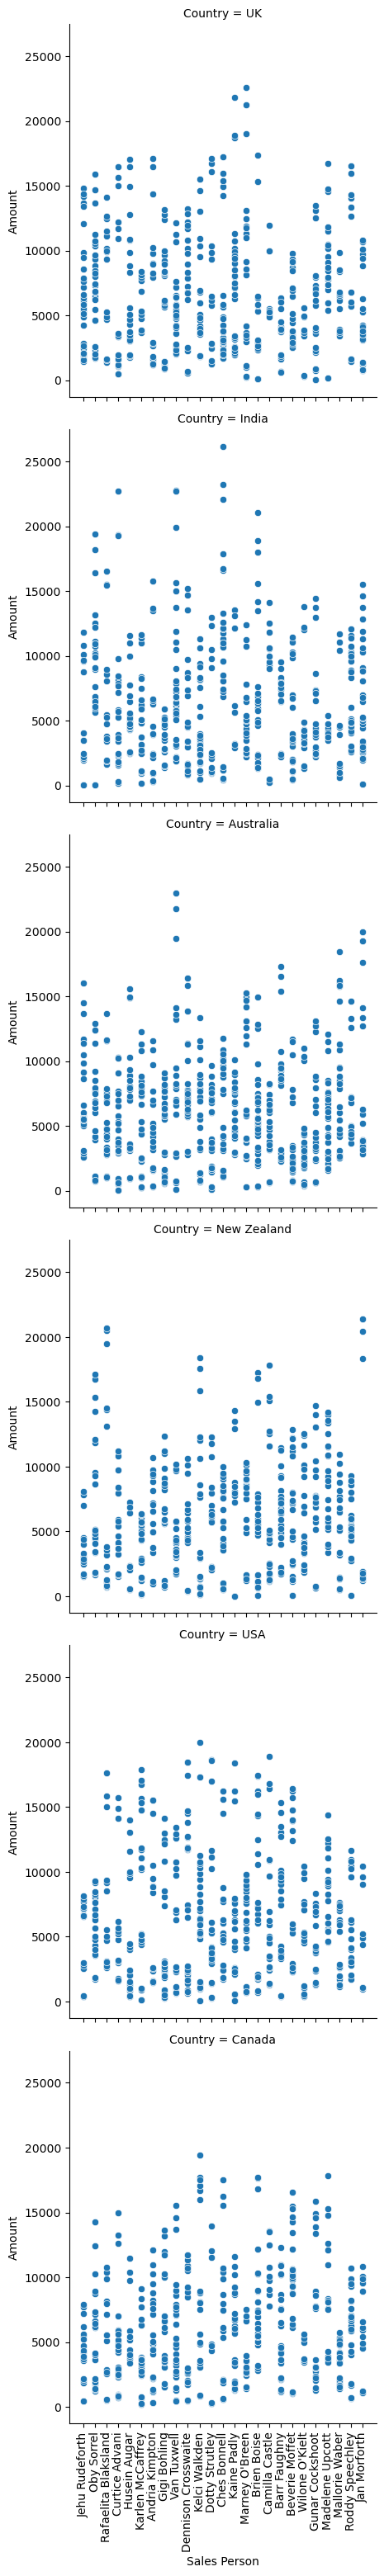

In [39]:
plt.figure(figsize=(12, 6))
sns.relplot(data=Sales,x="Sales Person",y="Amount",row="Country")
plt.xticks(rotation=90)
plt.show() # To represent Relplot graph of sales person and amount in row as Country

<Figure size 1200x600 with 0 Axes>

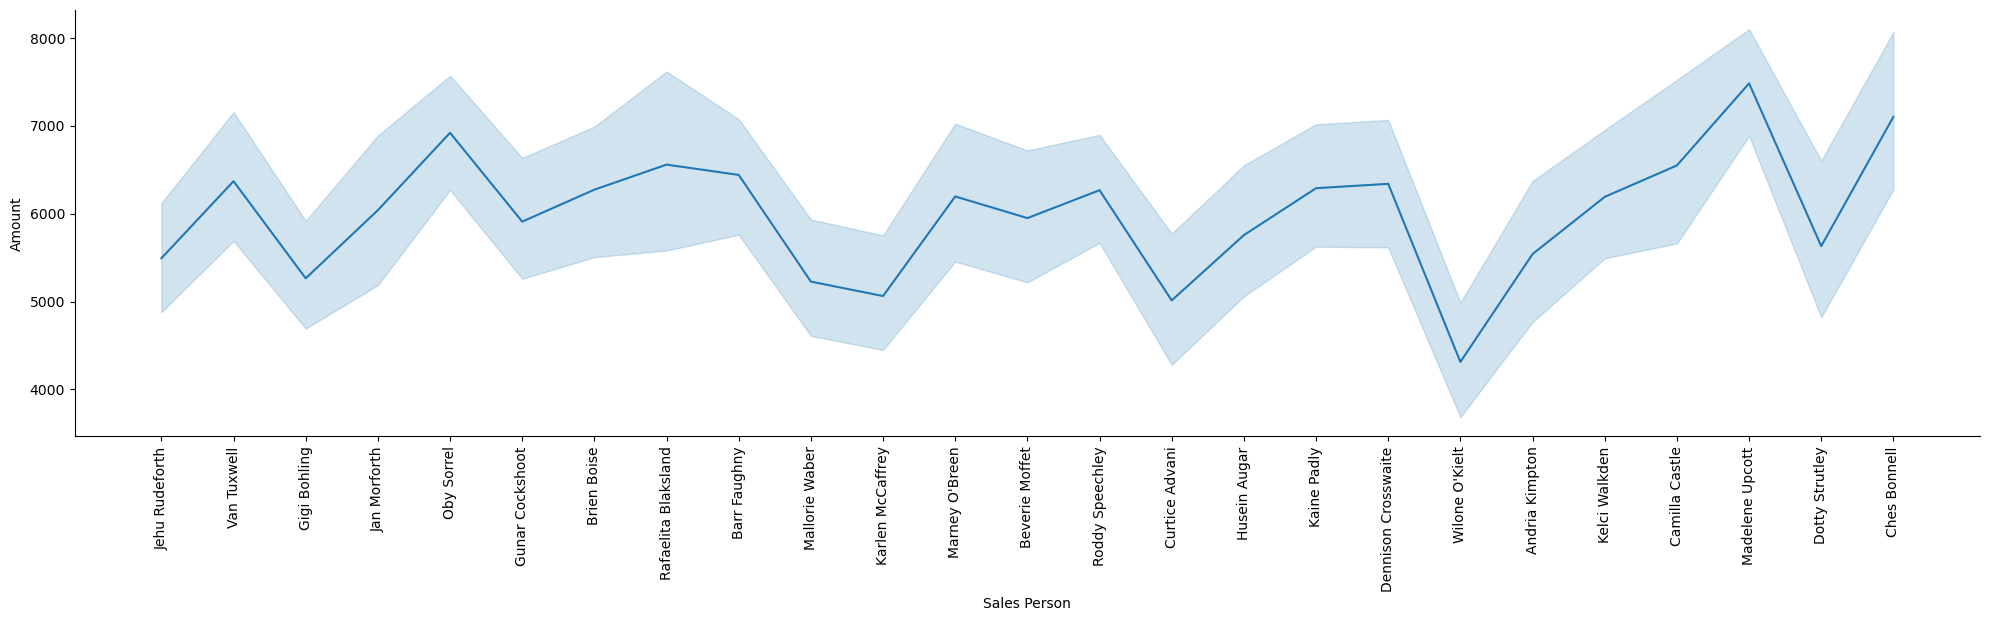

In [40]:
plt.figure(figsize=(12, 6))
sns.relplot(data=Sales,x="Sales Person",y="Amount",kind="line",aspect=4)
plt.xticks(rotation=90)
plt.show() # To represent Relplot graph of sales person and amount in line kind

Regplot

DTypePromotionError: The DType <class 'numpy.dtypes._PyFloatDType'> could not be promoted by <class 'numpy.dtypes.StrDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyFloatDType'>)

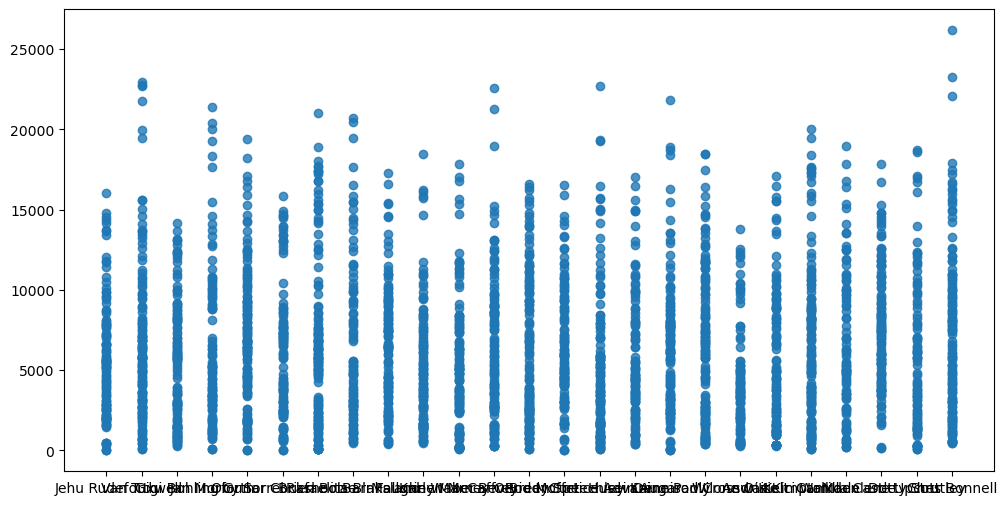

In [41]:
plt.figure(figsize=(12, 6))
sns.regplot(data=Sales,x="Sales Person",y="Amount")
plt.xticks(rotation=90)
plt.show() # To represent Regplot graph of sales person and amount 

Pairplot

In [42]:
pp1=Sales.loc[:, ['Sales Person', 'Product_Name', 'Amount', 'Country', 'Boxes Shipped']]
pp1.info() # To create pairplot

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Product_Name   3282 non-null   object
 2   Amount         3282 non-null   int64 
 3   Country        3282 non-null   object
 4   Boxes Shipped  3282 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 128.3+ KB


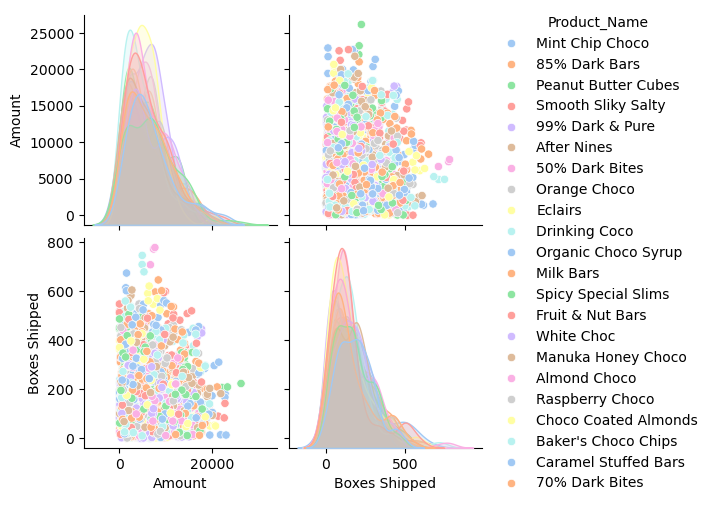

In [43]:
sns.pairplot(pp1, hue = "Product_Name", palette = 'pastel')
plt.show()

In [44]:
pp2=Sales.loc[:, ['Sales Person', 'Product_Name', 'Amount','Date','Boxes Shipped']]
pp2.info() # To create pairplot

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   3282 non-null   object        
 1   Product_Name   3282 non-null   object        
 2   Amount         3282 non-null   int64         
 3   Date           3282 non-null   datetime64[ns]
 4   Boxes Shipped  3282 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 128.3+ KB


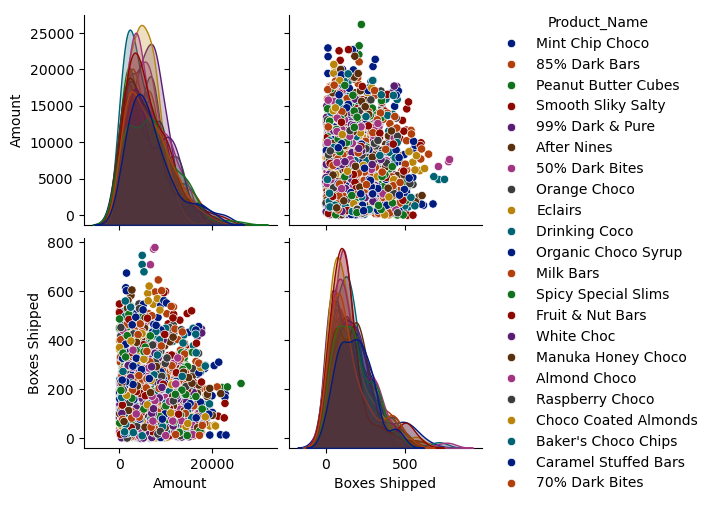

In [45]:
sns.pairplot(pp2, hue = "Product_Name", palette = 'dark')
plt.show()

In [46]:
pp3=Sales.loc[:, ['Sales Person', 'Product_Name','Price_Per_Box', 'Boxes Shipped','Date']]
pp3.info() # To create pairplot

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   3282 non-null   object        
 1   Product_Name   3282 non-null   object        
 2   Price_Per_Box  3282 non-null   float64       
 3   Boxes Shipped  3282 non-null   int64         
 4   Date           3282 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 128.3+ KB


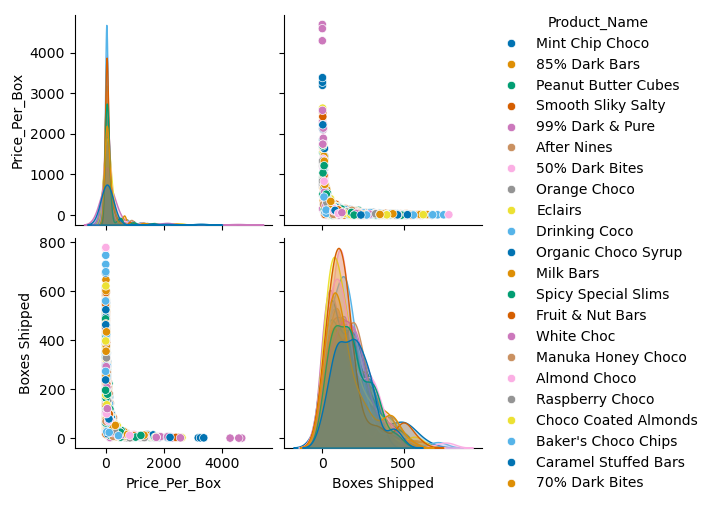

In [47]:
sns.pairplot(pp3, hue = "Product_Name", palette = 'colorblind')
plt.show()

In [48]:
hm = Sales.loc[:, ['Date','Amount', 'Boxes Shipped','Price_Per_Box']]
hm.info() # To create pairplot of numeric columns only

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           3282 non-null   datetime64[ns]
 1   Amount         3282 non-null   int64         
 2   Boxes Shipped  3282 non-null   int64         
 3   Price_Per_Box  3282 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 102.7 KB


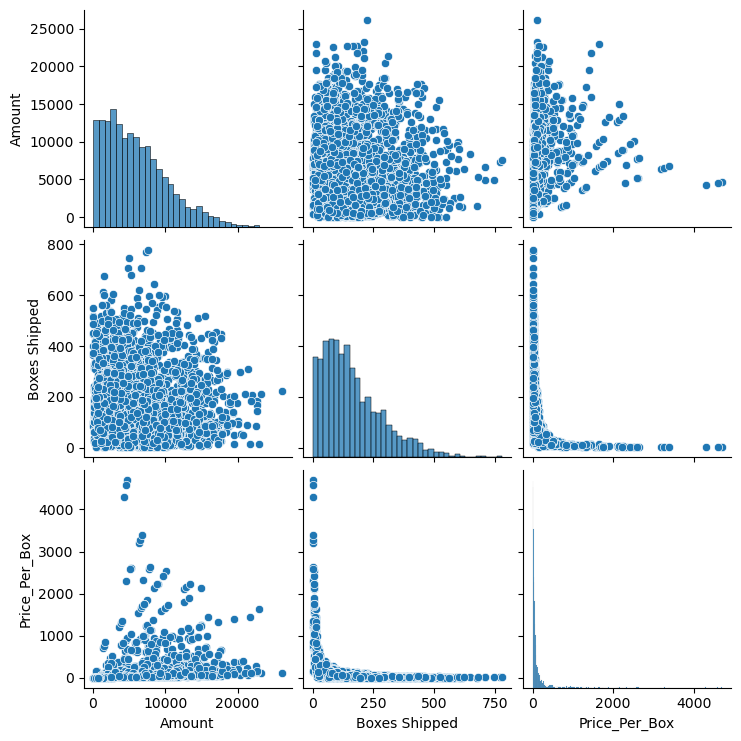

In [49]:
sns.pairplot(hm)
plt.show()

In [52]:
print("\n--- THANK YOU ---")


--- THANK YOU ---
